<a href="https://colab.research.google.com/github/KikoChagasBR/ML_DL/blob/main/RNN_Python_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
minimo = 20
maximo = 40
qtd_pontos = 100
np.random.seed(1234)
y = np.random.uniform(minimo, maximo, qtd_pontos)
x = np.arange (1,qtd_pontos+1,1)

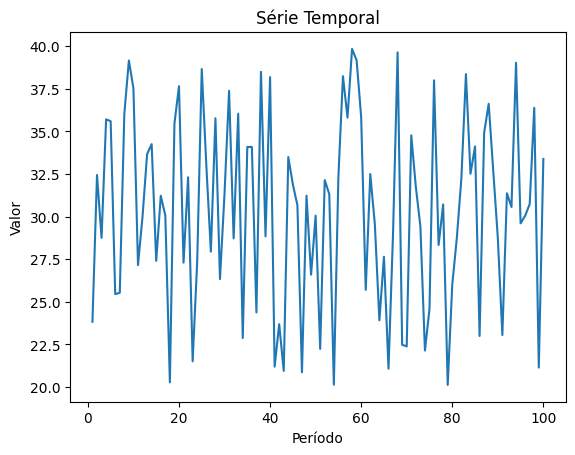

In [4]:
import matplotlib.pyplot as plt
plt.title('Série Temporal')
plt.xlabel('Período')
plt.ylabel('Valor')
plt.plot(x,y)
plt.show()

In [5]:
minimo = np.min(y)
maximo = np.max(y)
y = (y - minimo)/(maximo - minimo)

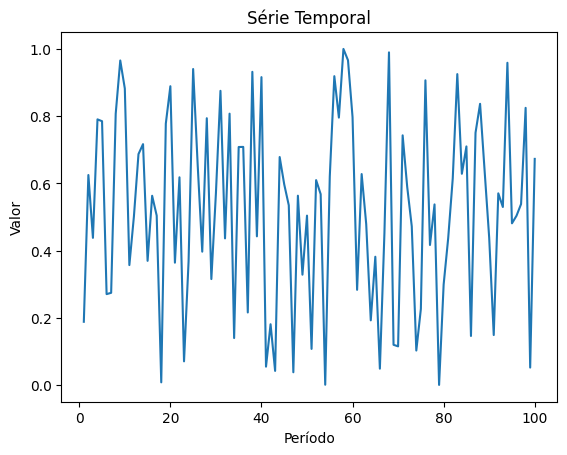

In [6]:
import matplotlib.pyplot as plt
plt.title('Série Temporal')
plt.xlabel('Período')
plt.ylabel('Valor')
plt.plot(x,y)
plt.show()

In [7]:
percentual_treinamento = 0.8
qtd_treinamento = int(percentual_treinamento*(len(x)));

x_treino = x[0:qtd_treinamento]
x_teste = x[qtd_treinamento:]

y_treino = y[0:qtd_treinamento]
y_teste = y[qtd_treinamento:]

treino = np.array(list(zip(x_treino, y_treino)))
teste = np.array(list(zip(x_teste, y_teste)))

In [10]:
for i in range(5):
    print('treino[{}]: {}'.format(i+1, treino[i]))

treino[1]: [1.         0.18796634]
treino[2]: [2.         0.62472579]
treino[3]: [3.         0.43770267]
treino[4]: [4.         0.79031489]
treino[5]: [5.         0.78485498]


In [14]:
def preparar_dados(dados_serie, look_back):
  X, y =[],[]
  n = len(dados_serie)
  for i in range(n - look_back):
    posicao_fim = i + look_back
    if posicao_fim <= n:
      seq_x = dados_serie[i:posicao_fim,1]
      seq_y = dados_serie[posicao_fim,1]
      X.append(seq_x)
      y.append(seq_y)
  return np.array(X), np.array(y)

In [15]:
look_back = 2
x_treino, y_treino = preparar_dados(treino, look_back)
x_teste, y_teste = preparar_dados(teste, look_back)

n_caracteristicas = 1
x_treino = x_treino.reshape((x_treino.shape[0],
                                x_treino.shape[1],
                                n_caracteristicas))
x_teste = x_teste.reshape((x_teste.shape[0],
                        x_teste.shape[1],
                        n_caracteristicas))

In [16]:
for i in range(5):
    print('treino[{}]: {} -> {}'.format(i+1,x_treino[i],y_treino[i]))

treino[1]: [[0.18796634]
 [0.62472579]] -> 0.43770267010016545
treino[2]: [[0.62472579]
 [0.43770267]] -> 0.7903148853427738
treino[3]: [[0.43770267]
 [0.79031489]] -> 0.7848549773524561
treino[4]: [[0.79031489]
 [0.78485498]] -> 0.27020123516246175
treino[5]: [[0.78485498]
 [0.27020124]] -> 0.2741283637666303


In [17]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
n_etapas = x_treino.shape[1]
n_caracteristicas = x_treino.shape[2]
n_unidades = 100
tf.random.set_seed(8888) # Setting seed to ensure reproducibility.
modelo = Sequential()
camada_de_entrada=(n_etapas, n_caracteristicas)
modelo.add(LSTM(n_unidades,
                return_sequences = True,
                input_shape = camada_de_entrada))
modelo.add(Dropout(0.2))
modelo.add(LSTM(128,
                input_shape = camada_de_entrada))
modelo.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,177 (617.88 KB)

 Trainable params: 158,177 (617.88 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
modelo.compile(loss = 'mean_squared_error',
           optimizer = 'adam')

In [20]:
epocas = 20
historico = modelo.fit(x_treino, y_treino,
                        epochs = epocas,
                        batch_size = 70,
                        verbose = 2,
                        shuffle = False,
                        validation_split = 0.3)

Epoch 1/20
1/1 - 5s - 5s/step - loss: 0.3567 - val_loss: 0.3180
Epoch 2/20
1/1 - 1s - 715ms/step - loss: 0.3402 - val_loss: 0.3030
Epoch 3/20
1/1 - 0s - 140ms/step - loss: 0.3244 - val_loss: 0.2884
Epoch 4/20
1/1 - 0s - 141ms/step - loss: 0.3094 - val_loss: 0.2740
Epoch 5/20
1/1 - 0s - 96ms/step - loss: 0.2942 - val_loss: 0.2595
Epoch 6/20
1/1 - 0s - 106ms/step - loss: 0.2789 - val_loss: 0.2450
Epoch 7/20
1/1 - 0s - 126ms/step - loss: 0.2635 - val_loss: 0.2303
Epoch 8/20
1/1 - 0s - 140ms/step - loss: 0.2475 - val_loss: 0.2156
Epoch 9/20
1/1 - 0s - 146ms/step - loss: 0.2329 - val_loss: 0.2007
Epoch 10/20
1/1 - 0s - 102ms/step - loss: 0.2164 - val_loss: 0.1859
Epoch 11/20
1/1 - 0s - 134ms/step - loss: 0.1999 - val_loss: 0.1712
Epoch 12/20
1/1 - 0s - 142ms/step - loss: 0.1835 - val_loss: 0.1570
Epoch 13/20
1/1 - 0s - 137ms/step - loss: 0.1685 - val_loss: 0.1435
Epoch 14/20
1/1 - 0s - 144ms/step - loss: 0.1522 - val_loss: 0.1311
Epoch 15/20
1/1 - 0s - 140ms/step - loss: 0.1393 - val_loss: 

In [21]:
import pandas as pd
hist = pd.DataFrame(historico.history)
hist.head()

,loss,val_loss
0,0.356721,0.317965
1,0.340167,0.303025
2,0.324379,0.288427
3,0.309350,0.273974
4,0.294244,0.259526


from matplotlib import pyplot as plt
_df_0['loss'].plot(kind='hist', bins=20, title='loss')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['val_loss'].plot(kind='hist', bins=20, title='val_loss')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='loss', y='val_loss', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['loss'].plot(kind='line', figsize=(8, 4), title='loss')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['val_loss'].plot(kind='line', figsize=(8, 4), title='val_loss')
plt.gca().spines[['top', 'right']].set_visible(False)

In [24]:
modelo.save_weights('Meu_Modelo_LSTM.weights.h5')

In [25]:
loss = modelo.evaluate(x_teste, y_teste, batch_size=64)
print('loss: {}'.format(loss))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0792
loss: 0.07916811853647232


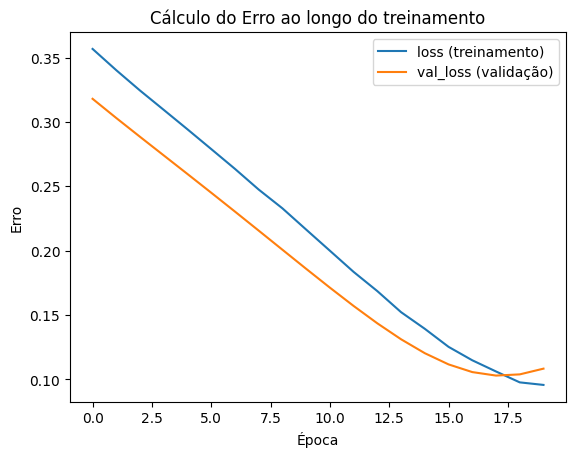

In [26]:
plt.title('Cálculo do Erro ao longo do treinamento')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.legend(['loss (treinamento)', 'val_loss (validação)'], loc='upper right')
plt.show()

In [27]:
modelo.load_weights('Meu_Modelo_LSTM.weights.h5')
predicao = modelo.predict(x_teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


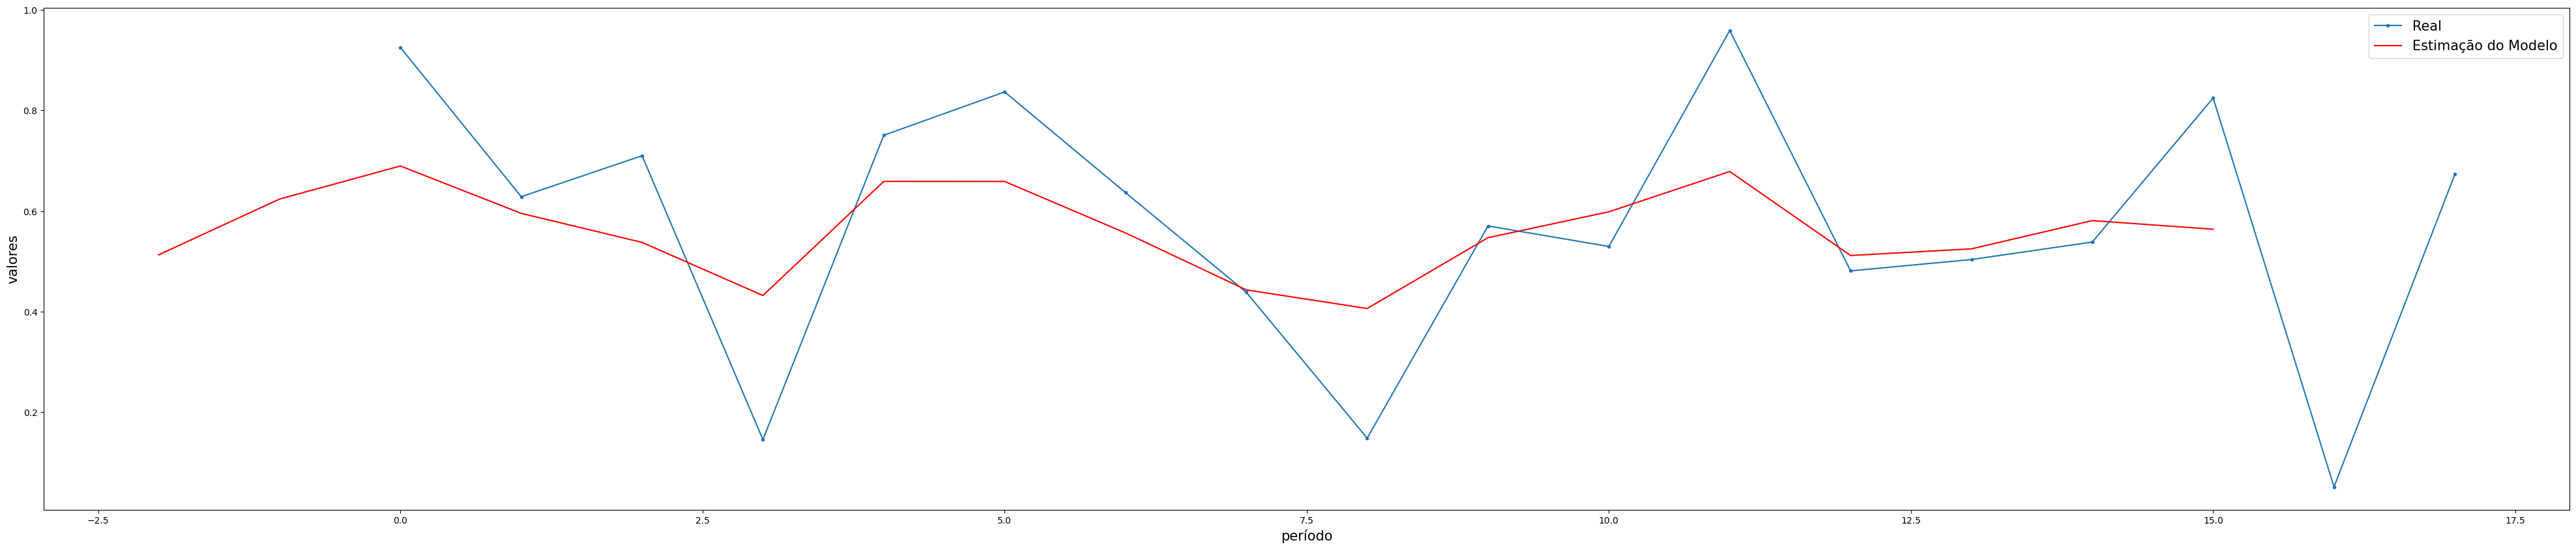

In [29]:
valores_reais_y = y_teste
plt.figure(figsize=(50,10))
plt.plot(list(range(len(valores_reais_y))),
            valores_reais_y,
            marker='.',
            label='Real')
lst_dados_predicao=[w[0] for w in predicao]
plt.plot(list(np.arange(len(predicao))-look_back),
            lst_dados_predicao,
            'r',label='Estimação do Modelo')
plt.ylabel('valores', size=15)
plt.xlabel('período', size=15)
plt.legend(fontsize=15)
plt.show()